# Activation sweeps: Burgers (noise=0.7, stride_x=5)

This notebook sweeps `SimpleMLP` activation functions under the dataset setting used in `noise_test.ipynb` cell 46: `noise=0.7`, `stride_x=5`.

It trains `(u_model, symnet)` for each activation and records:
- final losses
- `symnet.readout.weight`
- `symnet.effective_quadratic_matrix()`
- recovered coefficient proxy for `u*u_x` via `M[u,ux] + M[ux,u]` (if `selected_derivs=('u','u_x','u_xx')`)
- derivative sanity check: `||ux_fd - ux_autograd||_inf` on one time slice


In [1]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer
import Datasets.matconv as mc

# Repro (model init / batching)
SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [2]:
# Dataset + training settings (matches the 'noise=0.7, stride_x=5' layout)

noise = 0.7
nu = 0.02
stride_t = 1
stride_x = 5
part_num = 1
which_part = 1
seed = SEED

selected_derivs = ('u','u_x','u_xx')

lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 1000

lam_pde = 0.5
lam_reg = 0.0
lam_tv  = 0.0
lam_data = 10.0


In [3]:
# Build dataset

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=seed,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 13104
x_unique: 52 t_unique: 252


In [4]:
# Activations to sweep

ACTS = {
    'sin': mlps.Sin,
    'tanh': nn.Tanh,
    'relu': nn.ReLU,
    'silu': nn.SiLU,
    'softplus': nn.Softplus,
}

list(ACTS.keys())


['sin', 'tanh', 'relu', 'silu', 'softplus']

In [5]:
def make_models(act_cls):
    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=act_cls)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet


def make_trainer(u_model, symnet):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )


def one_batch():
    idx = torch.randint(0, t_torch.shape[0], (batch_size,), device=device)
    t = t_torch[idx][:, None].float().requires_grad_(True)
    x = x_torch[idx][:, None].float().requires_grad_(True)
    u_noisy = y_noisy_torch[idx][:, None].float()
    u_clean = y_clean_torch[idx][:, None].float()
    return t, x, u_noisy, u_clean


def fd_ux(u_row, x_unique):
    dx = np.diff(x_unique)
    du = np.diff(u_row)
    ux_fd = du / dx
    x_mid = 0.5 * (x_unique[1:] + x_unique[:-1])
    return x_mid, ux_fd


def ux_autograd(model, t0, x_unique):
    x_t = torch.tensor(x_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
    t_t = torch.full_like(x_t, float(t0))
    u_out = model(t_t, x_t)
    ux = torch.autograd.grad(
        u_out, x_t,
        grad_outputs=torch.ones_like(u_out),
        create_graph=False,
        retain_graph=False,
    )[0]
    return ux.detach().cpu().numpy().ravel()


def run_activation(name, act_cls):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    u_model, symnet = make_models(act_cls)
    train = make_trainer(u_model, symnet)

    loss_dat = []
    loss_pde = []

    for i in range(steps):
        t, x, u_noisy, u_clean = one_batch()
        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean)
        loss_dat.append(out['loss_data'])
        loss_pde.append(out['loss_pde'])
        if log_every and i % log_every == 0:
            print(f'[{name}] step {i}: data={out["loss_data"]:.3e} pde={out["loss_pde"]:.3e}')

    M_sym = symnet.effective_quadratic_matrix(symmetrize=True).detach().cpu().numpy()

    i_u, i_ux, i_uxx = 0, 1, 2
    coef_uux = float(M_sym[i_u, i_ux] + M_sym[i_ux, i_u])
    coef_uxx = float(symnet.readout.weight[0, i_uxx].detach().cpu().item())
    w_prod = float(symnet.readout.weight[0, -1].detach().cpu().item())

    # derivative check (FD on clean solver grid, autograd on trained model)
    t_unique = np.unique(t_np)
    x_unique = np.unique(x_np)
    Nt, Nx = len(t_unique), len(x_unique)

    t_to_i = {v: i for i, v in enumerate(t_unique)}
    x_to_j = {v: j for j, v in enumerate(x_unique)}
    U = np.full((Nt, Nx), np.nan, dtype=np.float64)
    for tt, xx, yy in zip(t_np, x_np, y_np):
        U[t_to_i[tt], x_to_j[xx]] = yy

    k = max(0, Nt - 2)
    t0 = t_unique[k]
    u_row = U[k, :]

    x_mid, ux_fd = fd_ux(u_row, x_unique)
    ux_ag = ux_autograd(train.u, t0, x_unique)
    ux_ag_clip = ux_ag[1:]
    ux_err_inf = float(np.max(np.abs(ux_fd - ux_ag_clip)))

    return {
        'act': name,
        'train': train,
        'loss_data_final': float(loss_dat[-1]),
        'loss_pde_final': float(loss_pde[-1]),
        'coef_uux_sym': coef_uux,
        'coef_uxx': coef_uxx,
        'w_prod': w_prod,
        'ux_err_inf': ux_err_inf,
        'M_sym': M_sym,
        'readout_w': symnet.readout.weight.detach().cpu().numpy().copy(),
        'linear_w': symnet.linear.weight.detach().cpu().numpy().copy(),
    }


In [8]:
# Run sweep

results = []
for name, act_cls in ACTS.items():
    print('===', name, '===')
    res = run_activation(name, act_cls)
    results.append(res)

print('--- Summary ---')
for r in results:
    print(
        f"{r['act']:>8} | loss_data={r['loss_data_final']:.3e} loss_pde={r['loss_pde_final']:.3e} "
        f"coef_uux_sym={r['coef_uux_sym']:+.3f} coef_uxx={r['coef_uxx']:+.4f} w_prod={r['w_prod']:+.3f} "
        f"ux_err_inf={r['ux_err_inf']:.3e}"
    )


=== sin ===
[sin] step 0: data=9.141e-01 pde=7.763e-03
[sin] step 1000: data=4.633e-01 pde=7.569e-03
[sin] step 2000: data=4.902e-01 pde=1.253e-02
[sin] step 3000: data=5.243e-01 pde=5.969e-03
[sin] step 4000: data=5.103e-01 pde=7.562e-03
[sin] step 5000: data=4.719e-01 pde=6.706e-03
[sin] step 6000: data=4.976e-01 pde=6.390e-03
[sin] step 7000: data=4.859e-01 pde=5.939e-03
=== tanh ===
[tanh] step 0: data=9.260e-01 pde=3.493e-03
[tanh] step 1000: data=4.588e-01 pde=1.227e-02
[tanh] step 2000: data=4.848e-01 pde=8.611e-03
[tanh] step 3000: data=5.271e-01 pde=9.807e-03
[tanh] step 4000: data=5.150e-01 pde=7.441e-03
[tanh] step 5000: data=4.780e-01 pde=5.614e-03
[tanh] step 6000: data=4.988e-01 pde=6.190e-03
[tanh] step 7000: data=4.860e-01 pde=4.602e-03
=== relu ===
[relu] step 0: data=9.335e-01 pde=8.628e-05
[relu] step 1000: data=4.537e-01 pde=1.834e-02
[relu] step 2000: data=4.883e-01 pde=2.067e-02
[relu] step 3000: data=5.226e-01 pde=2.542e-02
[relu] step 4000: data=5.107e-01 pde=2.

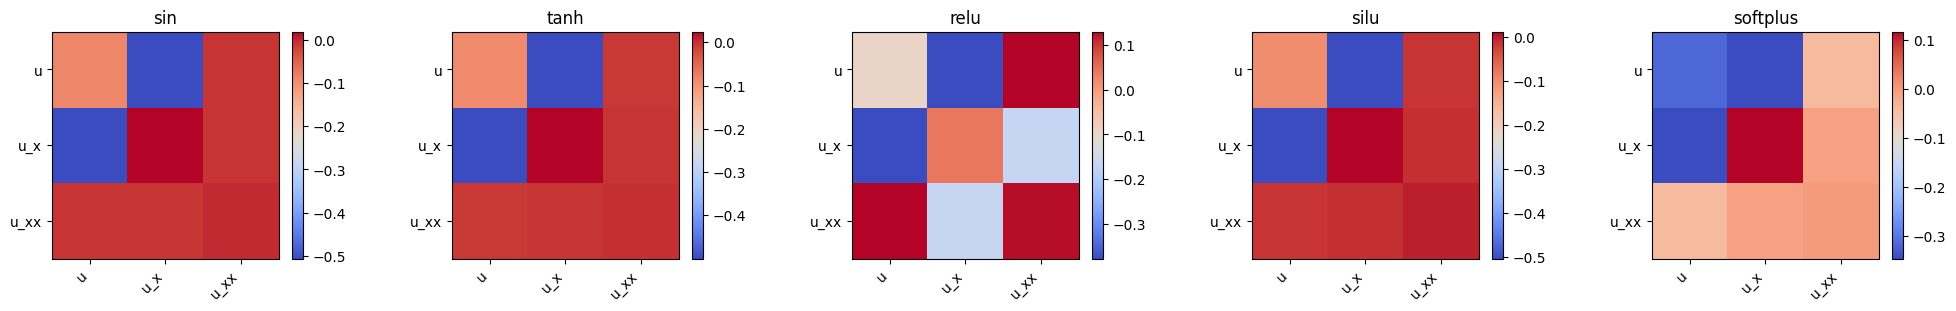

In [9]:
# Visualize learned effective quadratic matrices

fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 3), constrained_layout=True)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    im = ax.imshow(r['M_sym'], cmap='coolwarm')
    ax.set_title(r['act'])
    ax.set_xticks(range(len(selected_derivs)))
    ax.set_yticks(range(len(selected_derivs)))
    ax.set_xticklabels(selected_derivs, rotation=45, ha='right')
    ax.set_yticklabels(selected_derivs)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()


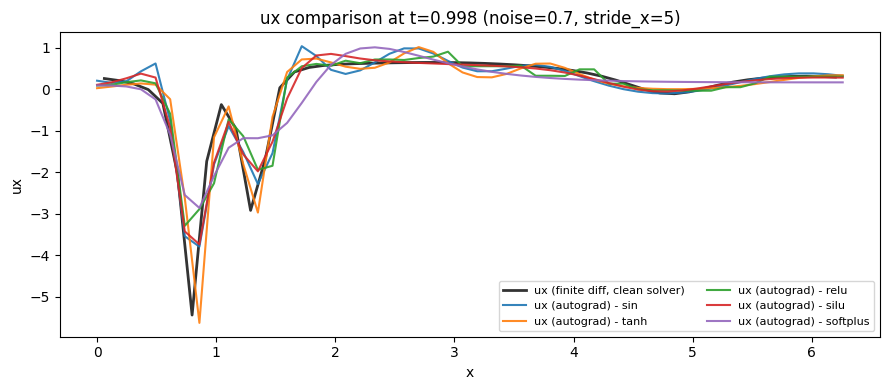

In [10]:
# Derivative overlay: ux (FD on clean solver) vs ux (autograd on each activation's trained model)

# Build clean grid once
t_unique = np.unique(t_np)
x_unique = np.unique(x_np)
Nt, Nx = len(t_unique), len(x_unique)

t_to_i = {v: i for i, v in enumerate(t_unique)}
x_to_j = {v: j for j, v in enumerate(x_unique)}
U = np.full((Nt, Nx), np.nan, dtype=np.float64)
for tt, xx, yy in zip(t_np, x_np, y_np):
    U[t_to_i[tt], x_to_j[xx]] = yy

# pick a time slice
k = max(0, Nt - 2)
t0 = t_unique[k]
u_row = U[k, :]

x_mid, ux_fd = fd_ux(u_row, x_unique)

plt.figure(figsize=(9,4))
plt.plot(x_mid, ux_fd, label='ux (finite diff, clean solver)', linewidth=2, color='black', alpha=0.8)

for r in results:
    ux_ag = ux_autograd(r['train'].u, t0, x_unique)
    plt.plot(x_unique, ux_ag, label=f"ux (autograd) - {r['act']}", linewidth=1.5, alpha=0.9)

plt.title(f"ux comparison at t={float(t0):.4g} (noise={noise}, stride_x={stride_x})")
plt.xlabel('x')
plt.ylabel('ux')
plt.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()


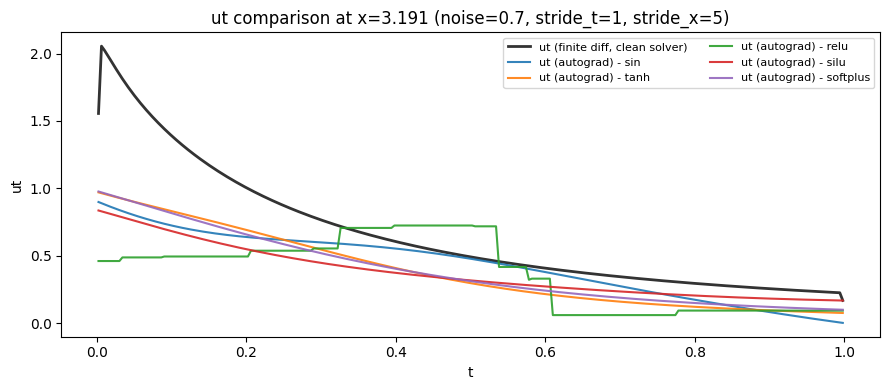

In [11]:
# Derivative overlay: ut (FD on clean solver) vs ut (autograd on each activation's trained model)

def grad1(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

def ut_autograd(u_model, x0: float, t_unique, device):
    """
    Returns ut(t, x0) evaluated at all t in t_unique using autograd.
    Output shape: (Nt,)
    """
    t_t = torch.tensor(t_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)  # (Nt,1)
    x_t = torch.full_like(t_t, float(x0))  # (Nt,1)
    u_out = u_model(t_t, x_t)              # (Nt,1)
    ut = grad1(u_out, t_t)                 # (Nt,1)
    return ut.detach().cpu().numpy().ravel()

# --- Build clean grid once (same as your ux overlay) ---
t_unique = np.unique(t_np)
x_unique = np.unique(x_np)
Nt, Nx = len(t_unique), len(x_unique)

t_to_i = {v: i for i, v in enumerate(t_unique)}
x_to_j = {v: j for j, v in enumerate(x_unique)}

U = np.full((Nt, Nx), np.nan, dtype=np.float64)
for tt, xx, yy in zip(t_np, x_np, y_np):
    U[t_to_i[tt], x_to_j[xx]] = yy

# --- pick a fixed x0 (one of the grid x values) ---
x0 = float(x_unique[Nx // 2])
j0 = np.where(x_unique == x0)[0][0]

# --- FD reference: central difference in time at fixed x0 ---
u_tseries = U[:, j0]          # (Nt,)
dt0 = t_unique[1] - t_unique[0]

# central diff: length Nt-2
ut_fd_central = (u_tseries[2:] - u_tseries[:-2]) / (2.0 * dt0)
t_center = t_unique[1:-1]

# --- plot ---
plt.figure(figsize=(9, 4))
plt.plot(t_center, ut_fd_central, label="ut (finite diff, clean solver)", linewidth=2, color="black", alpha=0.8)

for r in results:
    train = r["train"]  # expects train.u to be the trained u-model
    u_model = train.u
    device = next(u_model.parameters()).device

    ut_ag = ut_autograd(u_model, x0, t_unique, device)  # (Nt,)
    plt.plot(t_center, ut_ag[1:-1], label=f"ut (autograd) - {r['act']}", linewidth=1.5, alpha=0.9)

plt.title(f"ut comparison at x={x0:.4g} (noise={noise}, stride_t={stride_t}, stride_x={stride_x})")
plt.xlabel("t")
plt.ylabel("ut")
plt.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()